# nb12 — σ-конфигурация как счёт, а не как средняя сделка

Всё, что мы мерили до сих пор, отвечало на вопрос «сколько платит средний сигнал».
Это не то же самое, что «что делает счёт». Расхождение возникает в момент, когда
сигналы приходят быстрее, чем освобождается капитал: у σ-группы среднее число
одновременных позиций 5.7, но **пик 76**, а значит при 2% gross на позицию пиковая
загрузка 152% — часть сигналов придётся пропустить, и оценка «сверху по обороту»
(nb11 §7: +1.5%/год при taker) съедет.

**Заодно убираем две подогнанные ручки.** В nb11 порог σ (0.825%) и порог half-life
(1.4ч) были взяты как перцентили распределения 2024 года — то есть подобраны на
данных. Здесь они заменяются на **кросс-секционные** правила, вычисляемые в каждый
рефит по текущему набору отобранных пар:

- берём верхний квинтиль по σ спреда **среди отобранных в этот день**;
- выкидываем нижний квинтиль по half-life **среди них же**.

Никаких констант, ничего не подобрано на истории, всё вычисляется из того, что
видно в момент решения. Если находка nb11 переживёт эту замену — она не была
артефактом двух порогов.

## Замораживаемое правило

| элемент | значение |
|---|---|
| бар / окно формации | 1ч / 3 дня (72 бара) |
| рефит | ежедневно, ADF на трейлинговом окне |
| отбор | t < −3.8 и β > 0 |
| ex-ante фильтр | верхний квинтиль σ, без нижнего квинтиля half-life (кросс-секционно) |
| вход | 2 < \|z\| ≤ 4 |
| выход | \|z\| < 0.5 (цель) / \|z\| > 4 (стоп) / 144ч (лимит) |
| приоритет при конкуренции | больший \|z\| |
| лимит | суммарный gross ≤ 100% капитала |
| капитал | $1000 |
| PnL | ход спреда + фандинг − косты (4 сценария) |

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
from _engine import *
from itertools import combinations
import time

MIN_DVOL_M = 5.0
STABLES = ["USDCUSDT", "USDEUSDT", "DAIUSDT", "TUSDUSDT", "FDUSDUSDT"]
px = load_panel("close", "1h")
dv = load_panel("dollarvol", "1h")
daily_m = dv.median() * 24 / 1e6
liq = sorted([s for s in px.columns if daily_m[s] >= MIN_DVOL_M and s not in STABLES])
LP = np.log(px.loc[TRAIN[0]:TRAIN[1], liq]).iloc[:-1]
PAIRS = [((a, b) if daily_m[a] <= daily_m[b] else (b, a)) for a, b in combinations(liq, 2)]
bk = Book(LP, liq, PAIRS)
L, THR = 3, -3.8
R = refit(bk, bk.nbars(L), THR)
CF = funding_index(bk.index, liq)
COSTS = {"taker 21": 0.21, "taker 14": 0.14, "maker 6": 0.06, "maker 3": 0.03}
print(f"пар {len(bk.PAIRS)}, часов {len(bk.index)}, рефитов {len(R.ends)}")
print(f"отобрано ADF: {R.sel.sum(axis=1).mean():.0f} пар/день ({R.sel.mean()*100:.1f}%)")

# --- кросс-секционный фильтр: считается внутри каждого рефита, констант нет ---
G_ = 1 + np.abs(R.B)
SDP = R.SD / G_ * 100.0                       # σ спреда, % от gross
with np.errstate(all="ignore"):
    HL = np.where(R.RHO < 0, np.log(0.5)/np.log1p(R.RHO), np.nan)

EXTRA = np.zeros_like(R.sel)
for k in range(R.sel.shape[0]):
    row = R.sel[k]
    if row.sum() < 10:
        continue
    s_hi = np.nanpercentile(SDP[k][row], 80)
    h_lo = np.nanpercentile(HL[k][row], 20)
    EXTRA[k] = (SDP[k] >= s_hi) & (HL[k] >= h_lo)
print(f"после кросс-секционного фильтра: {(R.sel & EXTRA).sum(axis=1).mean():.1f} "
      f"пар/день (было {R.sel.sum(axis=1).mean():.0f})")
print(f"порог σ гуляет по дням: медиана {np.nanmedian([np.nanpercentile(SDP[k][R.sel[k]],80) for k in range(len(SDP)) if R.sel[k].sum()>=10]):.3f}%, "
      f"в nb11 стояла жёсткая константа 0.825%")

пар 903, часов 13151, рефитов 546
отобрано ADF: 34 пар/день (3.7%)
после кросс-секционного фильтра: 6.5 пар/день (было 34)
порог σ гуляет по дням: медиана 0.673%, в nb11 стояла жёсткая константа 0.825%


## 1. Кандидаты и контроль: пережила ли находка замену порогов

Сначала список сделок-кандидатов (то же, что раньше), с почасовым путём PnL для
переоценки портфеля и с фандингом. Рядом — та же машинерия без σ-фильтра, чтобы
видеть, что фильтр даёт **на уровне портфеля**, а не только в среднем на сделку.

Контроль обязателен: если после отказа от подобранных констант средняя сделка
рухнет, значит nb11 показывал артефакт двух порогов.

In [2]:
def add_funding(d):
    iy, ix = bk.IY[d.pi.values], bk.IX[d.pi.values]
    dy = CF[d.i_out.values, iy] - CF[d.i_in.values, iy]
    dx = CF[d.i_out.values, ix] - CF[d.i_in.values, ix]
    d = d.copy()
    d["fund"] = -d.side.values * (dy - d.beta.values*dx) / d.g.values * 100
    d["gross_f"] = d.gross + d.fund
    return d


t0 = time.time()
CAND = {}
CAND["σ-фильтр"] = add_funding(sweep(bk, R, "REFIT", max_hold=2*bk.nbars(L),
                                     keep_path=True, extra_sel=EXTRA))
CAND["без фильтра"] = add_funding(sweep(bk, R, "REFIT", max_hold=2*bk.nbars(L),
                                        keep_path=True))
print(f"{time.time()-t0:.0f}s\n")
rows = []
for nm, d in CAND.items():
    rows.append({"набор": nm, "сделок": len(d), "пар": d.pair.nunique(),
                 "gross+ф %": round(d.gross_f.mean(), 4),
                 "std %": round(d.gross_f.std(), 3),
                 "ср/std": round(d.gross_f.mean()/d.gross_f.std(), 4),
                 "σ спреда %": round(d.sd_pct.median(), 3),
                 "медиана ч": int(d.hours.median()),
                 "фандинг %": round(d.fund.mean(), 4)})
print("КАНДИДАТЫ")
print(pd.DataFrame(rows).to_string(index=False))
print()
print("КОНТРОЛЬ ПРОТИВ nb11 (там пороги были константами, подобранными на 2024):")
print("  nb11: 2024 +0.264%, 2025H1 +0.238%, ср/std 0.09")
d = CAND["σ-фильтр"]
for lab, m in [("2024", d.t_in < pd.Timestamp("2025-01-01", tz="UTC")),
               ("2025H1", d.t_in >= pd.Timestamp("2025-01-01", tz="UTC"))]:
    s = d[m]
    print(f"  здесь {lab}: {s.gross_f.mean():+.4f}% на {len(s)} сделках, "
          f"ср/std {s.gross_f.mean()/s.gross_f.std():.4f}")
ok = d.gross_f.mean() > 0.15
print(f"  -> {'находка ПЕРЕЖИЛА отказ от подобранных порогов' if ok else 'ВНИМАНИЕ: без констант эффект слабее'}")

0s

КАНДИДАТЫ
      набор  сделок  пар  gross+ф %  std %  ср/std  σ спреда %  медиана ч  фандинг %
   σ-фильтр    4004  749     0.1713  2.434  0.0704       0.813          7    -0.0009
без фильтра   25653  903     0.0598  1.596  0.0375       0.459          6    -0.0001

КОНТРОЛЬ ПРОТИВ nb11 (там пороги были константами, подобранными на 2024):
  nb11: 2024 +0.264%, 2025H1 +0.238%, ср/std 0.09
  здесь 2024: +0.1907% на 2690 сделках, ср/std 0.0785
  здесь 2025H1: +0.1317% на 1314 сделках, ср/std 0.0540
  -> находка ПЕРЕЖИЛА отказ от подобранных порогов


## 2. Портфель: во что это превращается на счёте

Ключевой вопрос — сколько сигналов вообще влезает. Прогоняем два режима, которые
пользователь просил сравнить ещё в nb04:

- **MULTI** — по символу можно держать несколько позиций одновременно (символ
  встречается в разных парах);
- **SINGLE** — не больше одной позиции на символ.

И перебираем размер позиции: слишком большой упирается в лимит gross и заставляет
пропускать сигналы, слишком маленький оставляет капитал простаивать.

In [3]:
rows = []
RUN = {}
for nm in ["σ-фильтр", "без фильтра"]:
    for f_pos in [0.01, 0.013, 0.02, 0.05]:
        for ops in [False, True]:
            E, log, st, dg = portfolio(bk, CAND[nm], f_pos=f_pos, one_per_symbol=ops,
                                       cost_pct=0.21)
            RUN[(nm, f_pos, ops)] = (E, log, st, dg)
            rows.append({"набор": nm, "размер поз %": f_pos*100,
                         "режим": "SINGLE" if ops else "MULTI", **st})
P = pd.DataFrame(rows)
show_cols = ["набор", "размер поз %", "режим", "годовая %", "макс DD %", "Sharpe",
             "сделок взято", "% взято", "ср. gross загрузка %", "макс gross %",
             "ср. |net| экспозиция %", "макс |net| %"]
print("ПОРТФЕЛЬ, кост taker 21 bps")
print(P[show_cols].to_string(index=False))
print()
print("как читать '% взято': сколько кандидатов реально исполнено. Всё, что ниже")
print("100%, съедено лимитом gross — то есть оценка 'сверху по обороту' была")
print("завышена ровно на эту долю.")

ПОРТФЕЛЬ, кост taker 21 bps
      набор  размер поз %  режим  годовая %  макс DD %  Sharpe  сделок взято  % взято  ср. gross загрузка %  макс gross %  ср. |net| экспозиция %  макс |net| %
   σ-фильтр           1.0  MULTI      -1.06      -3.30   -0.40          4004    100.0                   3.2          29.1                     1.1          20.7
   σ-фильтр           1.0 SINGLE      -1.29      -2.49   -1.60          1874     46.8                   1.4           6.0                     0.4           4.3
   σ-фильтр           1.3  MULTI      -1.40      -4.28   -0.40          4004    100.0                   4.2          37.8                     1.4          27.0
   σ-фильтр           1.3 SINGLE      -1.67      -3.22   -1.60          1874     46.8                   1.8           7.8                     0.5           5.6
   σ-фильтр           2.0  MULTI      -2.19      -6.53   -0.40          4004    100.0                   6.4          58.3                     2.1          41.5
   σ-фильтр 

## 3. Косты — та же развилка, но теперь на счёте

выбранный размер позиции: 5.0% (пик gross 96.6%, взято 99.2% сигналов)



ГОДОВАЯ ДОХОДНОСТЬ ПРИ РАЗНЫХ КОСТАХ (размер позиции 5.0%, MULTI)
      набор     кост  годовая %  итог $  макс DD %  Sharpe  сделок  % взято  загрузка %
   σ-фильтр taker 21      -8.15   880.5     -16.53   -0.62    3973     99.2        15.8
   σ-фильтр taker 14       0.78  1011.8     -12.36    0.12    3973     99.2        15.8
   σ-фильтр  maker 6      12.06  1185.9     -10.06    0.98    3973     99.2        15.8
   σ-фильтр  maker 3      16.60  1258.6      -9.19    1.30    3973     99.2        15.8
без фильтра taker 21     -69.02   172.9     -82.85   -7.18   19449     75.8        62.0
без фильтра taker 14     -51.36   339.8     -66.67   -4.39   19485     76.0        62.0
без фильтра  maker 6     -16.77   759.7     -31.79   -1.06   19550     76.2        62.3
без фильтра  maker 3       2.17  1032.7     -14.71    0.21   19553     76.2        62.3

сравнение с оценкой 'сверху по обороту' из nb11 §8:
  там было: taker 21 +1.5%, taker 14 +5.3%, maker 6 +9.7%, maker 3 +11.3%
  портфель, tak

[saved] notebooks\statarb\_out\nb12_equity.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb12_equity.png')

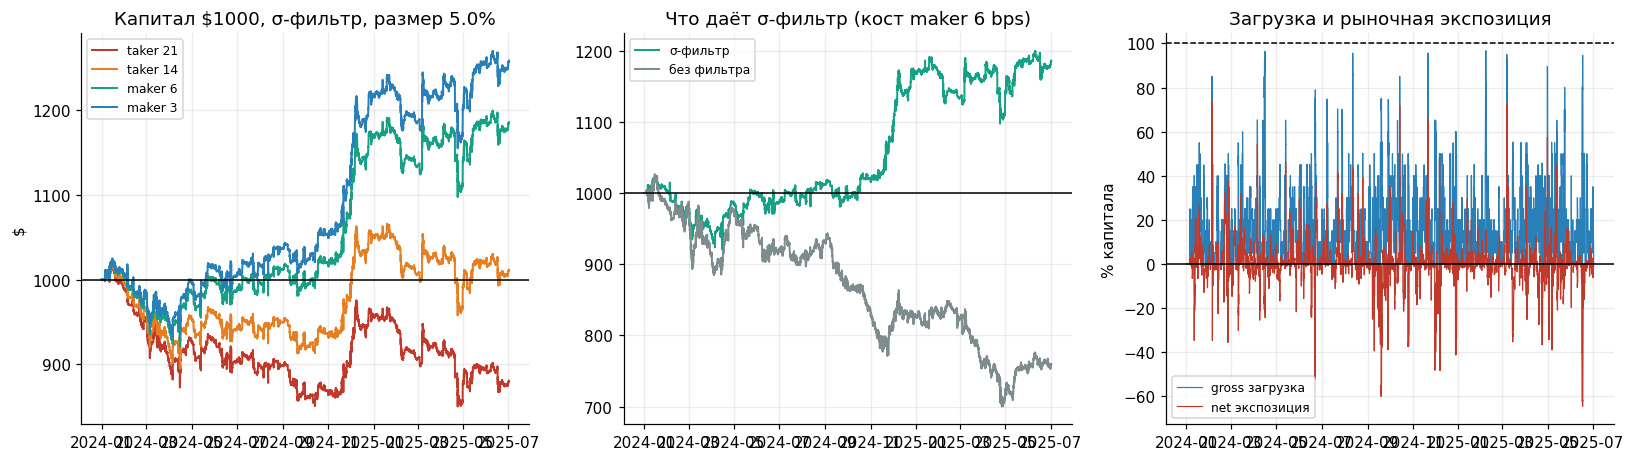

In [4]:
# размер позиции берём как самый крупный, при котором пик gross ещё не бьётся
# в лимит: так капитал работает максимально, но сигналы не отбрасываются
cands_f = [f for f in [0.01, 0.013, 0.02, 0.05]
           if RUN[("σ-фильтр", f, False)][2]["макс gross %"] <= 101.0]
F_POS = max(cands_f) if cands_f else 0.01
print(f"выбранный размер позиции: {F_POS*100:.1f}% "
      f"(пик gross {RUN[('σ-фильтр', F_POS, False)][2]['макс gross %']:.1f}%, "
      f"взято {RUN[('σ-фильтр', F_POS, False)][2]['% взято']:.1f}% сигналов)")
print()
rows = []
BEST = {}
for nm in ["σ-фильтр", "без фильтра"]:
    for cname, c in COSTS.items():
        E, log, st, dg = portfolio(bk, CAND[nm], f_pos=F_POS, one_per_symbol=False,
                                   cost_pct=c)
        BEST[(nm, cname)] = (E, log, st, dg)
        rows.append({"набор": nm, "кост": cname, "годовая %": st["годовая %"],
                     "итог $": st["итог"], "макс DD %": st["макс DD %"],
                     "Sharpe": st["Sharpe"], "сделок": st["сделок взято"],
                     "% взято": st["% взято"],
                     "загрузка %": st["ср. gross загрузка %"]})
C = pd.DataFrame(rows)
print(f"ГОДОВАЯ ДОХОДНОСТЬ ПРИ РАЗНЫХ КОСТАХ (размер позиции {F_POS*100:.1f}%, MULTI)")
print(C.to_string(index=False))
print()
print("сравнение с оценкой 'сверху по обороту' из nb11 §8:")
print("  там было: taker 21 +1.5%, taker 14 +5.3%, maker 6 +9.7%, maker 3 +11.3%")
for cname in COSTS:
    st = BEST[("σ-фильтр", cname)][2]
    print(f"  портфель, {cname}: {st['годовая %']:+.2f}%/год, DD {st['макс DD %']:.1f}%, "
          f"Sharpe {st['Sharpe']}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
for cname, col in [("taker 21", "#c0392b"), ("taker 14", "#e67e22"),
                   ("maker 6", "#16a085"), ("maker 3", "#2980b9")]:
    E = BEST[("σ-фильтр", cname)][0]
    ax[0].plot(E.index, E.values, lw=1.3, color=col, label=cname)
ax[0].axhline(1000, color="black", lw=1)
ax[0].set_title(f"Капитал $1000, σ-фильтр, размер {F_POS*100:.1f}%"); ax[0].legend(fontsize=8)
ax[0].set_ylabel("$")
for nm, col in [("σ-фильтр", "#16a085"), ("без фильтра", "#7f8c8d")]:
    E = BEST[(nm, "maker 6")][0]
    ax[1].plot(E.index, E.values, lw=1.3, color=col, label=nm)
ax[1].axhline(1000, color="black", lw=1)
ax[1].set_title("Что даёт σ-фильтр (кост maker 6 bps)"); ax[1].legend(fontsize=8)
dg = BEST[("σ-фильтр", "maker 6")][3]
ax[2].plot(dg.index, dg.gross*100, lw=0.8, color="#2980b9", label="gross загрузка")
ax[2].plot(dg.index, dg.net*100, lw=0.8, color="#c0392b", label="net экспозиция")
ax[2].axhline(100, color="black", ls="--", lw=1); ax[2].axhline(0, color="black", lw=1)
ax[2].set_ylabel("% капитала"); ax[2].legend(fontsize=8)
ax[2].set_title("Загрузка и рыночная экспозиция")
show("nb12_equity")

## 4. Рыночная нейтральность — цель пользователя

nb04 нашёл механизм смерти прошлой стратегии: каждая пара β-хеджирована, но
**сумма** по портфелю нет, и net-экспозиция гуляла ±70% капитала. Проверяем, что
стало теперь, когда позиций в среднем 5-8, а не 36.

Считаем: рыночный фактор как равновзвешенную доходность ликвидных символов,
корреляцию и β портфеля к нему, и результат в трендовые против боковых месяцев
(«эффективность тренда» = \|Σr\| / Σ\|r\| за месяц — насколько направленно рынок шёл).

корреляция часовых доходностей портфеля с рынком: +0.1008
β портфеля к рынку: +0.0149
net-экспозиция: средняя |net| 5.3%, макс |net| 73.8% (в nb04 без фильтра доходило до 70%)
доля времени |net| > 20%: 6.5%

ПО МЕСЯЦАМ (кост maker 6 bps)
           эффективность_тренда  доходность_%      режим
timestamp                                               
2024-02                   0.101        -2.494  трендовый
2024-03                   0.037        -3.629    боковой
2024-04                   0.076         4.601  трендовый
2024-05                   0.052         1.290  трендовый
2024-06                   0.060        -1.077  трендовый
2024-07                   0.020         1.002    боковой
2024-08                   0.039         1.529    боковой
2024-09                   0.039        -2.145  трендовый
2024-10                   0.020         2.559    боковой
2024-11                   0.101         6.577  трендовый
2024-12                   0.030         7.996    боковой
2025-01              

C:\Users\nvisary\AppData\Local\Temp\ipykernel_13120\1528098923.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  eff = mm.groupby(mm.index.to_period("M")).mkt.apply(
C:\Users\nvisary\AppData\Local\Temp\ipykernel_13120\1528098923.py:17: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  ret_m.index = ret_m.index.to_period("M")


[saved] notebooks\statarb\_out\nb12_neutral.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb12_neutral.png')

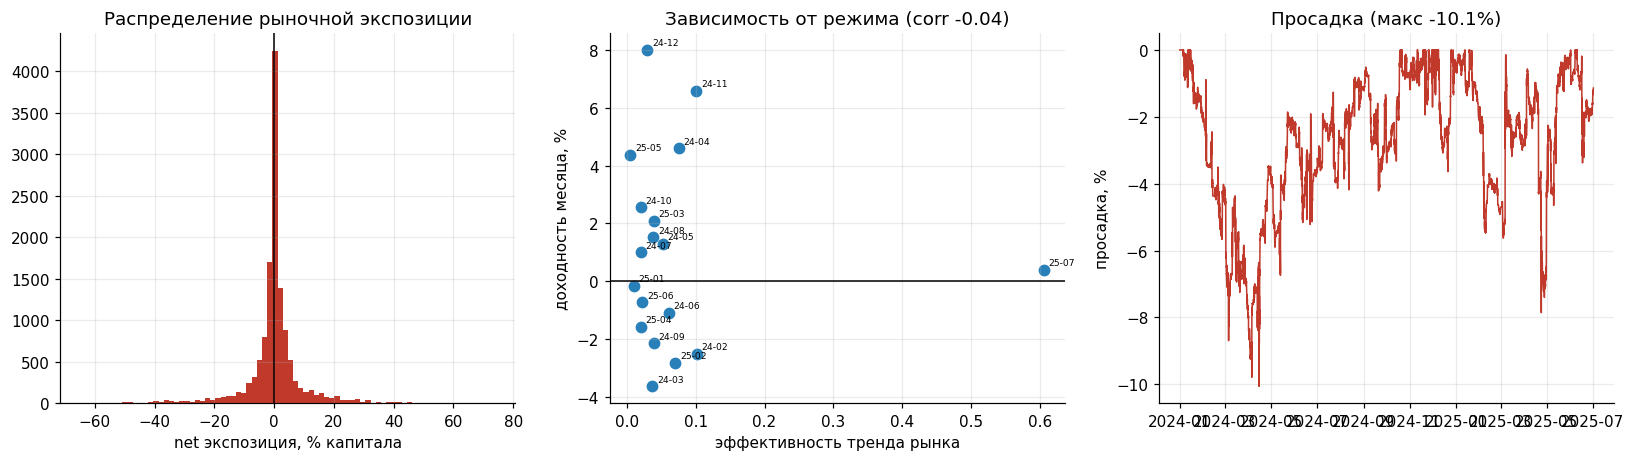

In [5]:
MKT = np.log(px.loc[bk.index[0]:bk.index[-1], liq]).diff().mean(axis=1).reindex(bk.index)
E, log, st, dg = BEST[("σ-фильтр", "maker 6")]
r_p = E.pct_change()
j = pd.DataFrame({"port": r_p, "mkt": MKT}).dropna()
print(f"корреляция часовых доходностей портфеля с рынком: {j.port.corr(j.mkt):+.4f}")
b = np.polyfit(j.mkt, j.port, 1)[0]
print(f"β портфеля к рынку: {b:+.4f}")
print(f"net-экспозиция: средняя |net| {np.abs(dg.net).mean()*100:.1f}%, "
      f"макс |net| {np.abs(dg.net).max()*100:.1f}% "
      f"(в nb04 без фильтра доходило до 70%)")
print(f"доля времени |net| > 20%: {(np.abs(dg.net) > 0.2).mean()*100:.1f}%")
print()
mm = pd.DataFrame({"mkt": MKT}).dropna()
eff = mm.groupby(mm.index.to_period("M")).mkt.apply(
    lambda x: abs(x.sum())/x.abs().sum())
ret_m = E.resample("MS").last().pct_change().dropna()
ret_m.index = ret_m.index.to_period("M")
k = pd.DataFrame({"эффективность_тренда": eff, "доходность_%": ret_m*100}).dropna()
k["режим"] = np.where(k.эффективность_тренда > k.эффективность_тренда.median(),
                      "трендовый", "боковой")
print("ПО МЕСЯЦАМ (кост maker 6 bps)")
print(k.round(3).to_string())
print()
print(k.groupby("режим").agg(месяцев=("доходность_%", "size"),
                             средняя=("доходность_%", "mean"),
                             плюсовых=("доходность_%", lambda x: int((x > 0).sum()))
                             ).round(2).to_string())
cc = k[["эффективность_тренда", "доходность_%"]].corr().iloc[0, 1]
print(f"\ncorr(трендовость месяца, доходность) = {cc:+.3f}")
print("в nb04 на нефильтрованном портфеле было -0.600 — стратегия умирала на трендах")
print(f"плюсовых месяцев всего: {int((k['доходность_%'] > 0).sum())} из {len(k)}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
ax[0].hist(dg.net*100, bins=80, color="#c0392b")
ax[0].axvline(0, color="black", lw=1)
ax[0].set_xlabel("net экспозиция, % капитала"); ax[0].set_title("Распределение рыночной экспозиции")
ax[1].scatter(k.эффективность_тренда, k["доходность_%"], s=45, color="#2980b9")
for _, r in k.iterrows():
    ax[1].annotate(str(r.name)[2:], (r.эффективность_тренда, r["доходность_%"]),
                   fontsize=6, xytext=(3, 3), textcoords="offset points")
ax[1].axhline(0, color="black", lw=1)
ax[1].set_xlabel("эффективность тренда рынка"); ax[1].set_ylabel("доходность месяца, %")
ax[1].set_title(f"Зависимость от режима (corr {cc:+.2f})")
ax[2].plot(dg.index, dg.dd*100, lw=1, color="#c0392b")
ax[2].set_ylabel("просадка, %"); ax[2].set_title(f"Просадка (макс {st['макс DD %']:.1f}%)")
show("nb12_neutral")

### 4b. 82% прироста — это два месяца. Почему, и что из этого следует

Кривая капитала обязывает проверить концентрацию числом. Если почти весь результат
пришёл из одного окна, то Sharpe 0.98 описывает не стратегию, а этот эпизод.

Гипотеза, которую надо проверить: кросс-секционный фильтр «верхний квинтиль σ»
устроен так, что квинтиль **существует всегда** — и в месяцы, когда абсолютная σ
спредов мала, мы всё равно торгуем, хотя кост в единицах σ там велик. Тогда
результат должен зависеть не от направления рынка (это мы уже проверили,
`corr = −0.04`), а от **абсолютного уровня σ** доступных спредов.

Если это так, у правила есть принципиальная, а не подогнанная поправка:
торговать только когда σ спреда кратно превышает кост. Порог задаётся не из
истории доходности, а из арифметики костов — `σ ≥ m × round-trip` — и мы смотрим
весь диапазон `m`, а не выбираем лучшее значение.

КОНЦЕНТРАЦИЯ РЕЗУЛЬТАТА
         сделок  σ_медиана  ход_σ  gross  волат_рынка_bps  доходность_%
m                                                                      
2024-02     177      0.813 -0.261 -0.225           48.097        -2.494
2024-03     202      1.242 -0.276 -0.307           67.597        -3.629
2024-04     240      1.010  0.317  0.503           69.977         4.601
2024-05     195      0.829  0.169  0.243           45.612         1.290
2024-06     181      0.950 -0.205 -0.090           44.021        -1.077
2024-07     191      0.839  0.116  0.168           51.446         1.002
2024-08     219      0.697  0.173  0.222           58.209         1.529
2024-09     301      0.816 -0.077 -0.084           49.460        -2.145
2024-10     267      0.582  0.291  0.250           49.679         2.559
2024-11     234      1.015  0.531  0.719           76.623         6.577
2024-12     284      0.953  0.271  0.544           83.061         7.996
2025-01     161      0.718 -0.031  0.063

C:\Users\nvisary\AppData\Local\Temp\ipykernel_13120\1714745805.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mret.index = mret.index.to_period("M")
C:\Users\nvisary\AppData\Local\Temp\ipykernel_13120\1714745805.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  d["m"] = d.t_in.dt.to_period("M")
C:\Users\nvisary\AppData\Local\Temp\ipykernel_13120\1714745805.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mv = pd.Series(MKT).abs().groupby(pd.Series(MKT).index.to_period("M")).mean()*1e4
C:\Users\nvisary\AppData\Local\Temp\ipykernel_13120\1714745805.py:45: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mr.index = mr.index.to_period("M")
C:\Users\nvisary\AppData\Local\Temp\ipykernel_13120\1714745805.py:45: UserWarning: Converting to PeriodArray/Index representation will drop timezone informat

C:\Users\nvisary\AppData\Local\Temp\ipykernel_13120\1714745805.py:45: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mr.index = mr.index.to_period("M")
C:\Users\nvisary\AppData\Local\Temp\ipykernel_13120\1714745805.py:45: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mr.index = mr.index.to_period("M")
C:\Users\nvisary\AppData\Local\Temp\ipykernel_13120\1714745805.py:45: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mr.index = mr.index.to_period("M")
C:\Users\nvisary\AppData\Local\Temp\ipykernel_13120\1714745805.py:45: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mr.index = mr.index.to_period("M")


C:\Users\nvisary\AppData\Local\Temp\ipykernel_13120\1714745805.py:45: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mr.index = mr.index.to_period("M")
C:\Users\nvisary\AppData\Local\Temp\ipykernel_13120\1714745805.py:45: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mr.index = mr.index.to_period("M")
C:\Users\nvisary\AppData\Local\Temp\ipykernel_13120\1714745805.py:45: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mr.index = mr.index.to_period("M")
C:\Users\nvisary\AppData\Local\Temp\ipykernel_13120\1714745805.py:45: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mr.index = mr.index.to_period("M")
C:\Users\nvisary\AppData\Local\Temp\ipykernel_13120\1714745805.py:45: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mr.index = mr.index.to_period("M")
C:\Us

C:\Users\nvisary\AppData\Local\Temp\ipykernel_13120\1714745805.py:45: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mr.index = mr.index.to_period("M")


 m  порог σ %     кост  сделок  σ медиана %  сделка %  годовая %  макс DD %  Sharpe  доля ноя+дек 24  2025H1 %  загрузка %
 0       0.00 taker 21    4004        0.813    0.1713      -8.15     -16.53   -0.62              NaN     -7.97        15.8
 0       0.00  maker 6    4004        0.813    0.1713      12.06     -10.06    0.98             81.0      1.43        15.8
 2       0.42 taker 21    3874        0.832    0.1844      -6.43     -15.32   -0.48              NaN     -7.11        15.4
 2       0.42  maker 6    3874        0.832    0.1844      13.41     -10.01    1.08             74.0      1.93        15.4
 3       0.63 taker 21    2882        0.978    0.2252      -1.81     -13.79   -0.09              NaN     -4.01        12.2
 3       0.63  maker 6    2882        0.978    0.2252      13.24     -10.01    1.09             72.0      2.02        12.2
 4       0.84 taker 21    1902        1.164    0.3576       6.94     -11.38    0.65            127.0      1.40         8.6
 4       0.84  m

[saved] notebooks\statarb\_out\nb12_concentration.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb12_concentration.png')

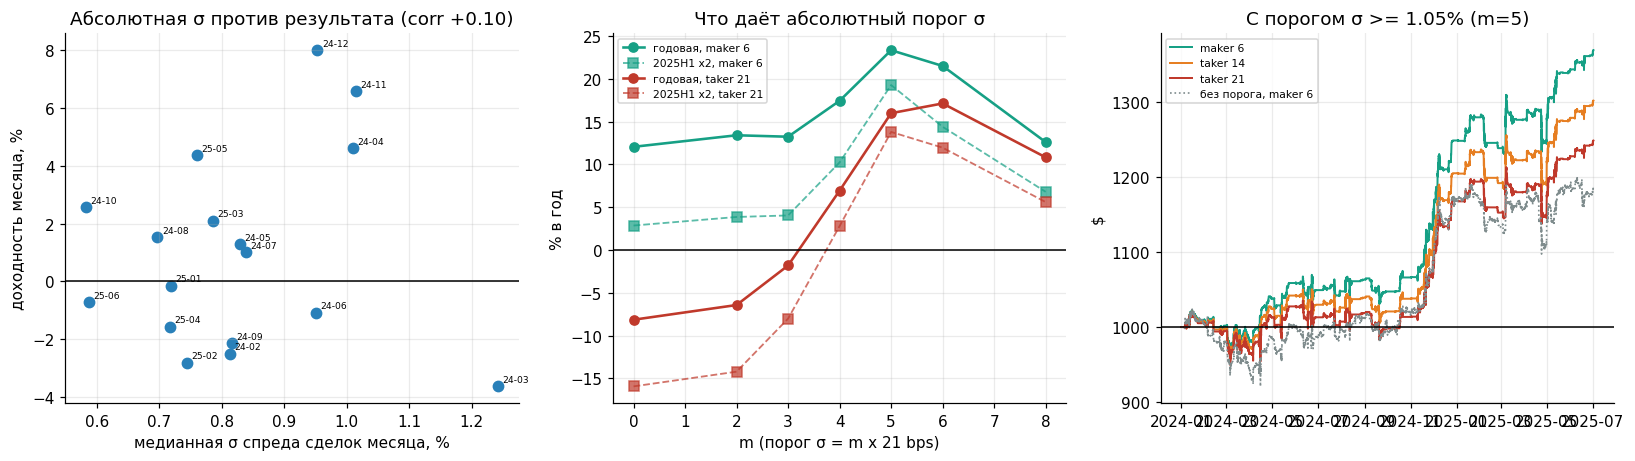

In [6]:
E6, log6, st6, dg6 = BEST[("σ-фильтр", "maker 6")]
mret = E6.resample("MS").last().pct_change().dropna()*100
mret.index = mret.index.to_period("M")
d = CAND["σ-фильтр"].copy()
d["m"] = d.t_in.dt.to_period("M")
agg = d.groupby("m").agg(сделок=("gross_f", "size"), σ_медиана=("sd_pct", "median"),
                         ход_σ=("sigma", "mean"), gross=("gross_f", "mean"))
mv = pd.Series(MKT).abs().groupby(pd.Series(MKT).index.to_period("M")).mean()*1e4
agg["волат_рынка_bps"] = mv
agg["доходность_%"] = mret
A = agg.dropna()
print("КОНЦЕНТРАЦИЯ РЕЗУЛЬТАТА")
print(A.round(3).to_string())
print()
tot = (E6.iloc[-1]/E6.iloc[0] - 1)*100
nd = (1 + mret.get(pd.Period("2024-11"), 0)/100)*(1 + mret.get(pd.Period("2024-12"), 0)/100) - 1
print(f"итог за весь TRAIN: {tot:+.2f}%")
print(f"ноябрь+декабрь 2024: {nd*100:+.2f}% -> {nd*100/tot*100:.0f}% всего итога")
rest = (1+tot/100)/(1+nd) - 1
print(f"остальные 16 месяцев вместе: {rest*100:+.2f}%")
h1 = np.prod([1+mret[p]/100 for p in mret.index if str(p) >= "2025-01"]) - 1
print(f"2025H1 (шесть месяцев): {h1*100:+.2f}%")
print()
for c in ["σ_медиана", "ход_σ", "сделок", "волат_рынка_bps"]:
    print(f"  corr(доходность месяца, {c:<16}) = "
          f"{A['доходность_%'].corr(A[c]):+.3f}")
print()
print("СРАВНЕНИЕ ДВУХ ОБЪЯСНЕНИЙ:")
print(f"  трендовость рынка:   corr {cc:+.3f}  (проверено в §4)")
print(f"  абсолютная σ спреда: corr {A['доходность_%'].corr(A['σ_медиана']):+.3f}")

# --- абсолютный порог σ, выведенный из костов, а не из доходности ---
print("\n\nАБСОЛЮТНЫЙ ПОРОГ σ, ЗАДАННЫЙ КОСТАМИ: σ >= m x round-trip")
print("(порог не подбирается по результату — показываем весь диапазон m)\n")
rows = []
for m_ in [0, 2, 3, 4, 5, 6, 8]:
    for cname, c in [("taker 21", 0.21), ("maker 6", 0.06)]:
        floor = m_ * 0.21          # порог всегда от БАЗОВОГО taker-коста, иначе
        sub = CAND["σ-фильтр"]     # правило зависело бы от сценария исполнения
        sub = sub[sub.sd_pct >= floor] if m_ > 0 else sub
        if len(sub) < 100:
            continue
        E, lg, st, dgx = portfolio(bk, sub, f_pos=F_POS, cost_pct=c)
        mr = E.resample("MS").last().pct_change().dropna()*100
        mr.index = mr.index.to_period("M")
        h1_ = np.prod([1+mr[p]/100 for p in mr.index if str(p) >= "2025-01"]) - 1
        nd_ = (1 + mr.get(pd.Period("2024-11"), 0)/100)*(1 + mr.get(pd.Period("2024-12"), 0)/100) - 1
        t_ = (E.iloc[-1]/E.iloc[0]-1)*100
        rows.append({"m": m_, "порог σ %": round(floor, 2), "кост": cname,
                     "сделок": len(sub), "σ медиана %": round(sub.sd_pct.median(), 3),
                     "сделка %": round(sub.gross_f.mean(), 4),
                     "годовая %": st["годовая %"], "макс DD %": st["макс DD %"],
                     "Sharpe": st["Sharpe"],
                     "доля ноя+дек 24": round(nd_*100/t_*100, 0) if t_ > 0 else np.nan,
                     "2025H1 %": round(h1_*100, 2),
                     "загрузка %": st["ср. gross загрузка %"]})
FL = pd.DataFrame(rows)
print(FL.to_string(index=False))
print()
print("что здесь важно: не 'какая годовая больше', а становится ли результат")
print("РОВНЕЕ — падает ли доля ноября-декабря и выходит ли 2025H1 из нуля.")
print()
for cname in ["maker 6", "taker 21"]:
    f = FL[FL.кост == cname]
    b = f.loc[f["2025H1 %"].idxmax()]
    print(f"  {cname}: лучший по 2025H1 порог m={b['m']:.0f} (σ>={b['порог σ %']:.2f}%): "
          f"2025H1 {b['2025H1 %']:+.2f}%, годовая {b['годовая %']:+.2f}%, "
          f"Sharpe {b['Sharpe']}, сделок {int(b['сделок'])}, "
          f"доля ноя+дек {b['доля ноя+дек 24']:.0f}%")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
ax[0].scatter(A["σ_медиана"], A["доходность_%"], s=45, color="#2980b9")
for p_, r in A.iterrows():
    ax[0].annotate(str(p_)[2:], (r["σ_медиана"], r["доходность_%"]), fontsize=6,
                   xytext=(3, 3), textcoords="offset points")
ax[0].axhline(0, color="black", lw=1)
ax[0].set_xlabel("медианная σ спреда сделок месяца, %")
ax[0].set_ylabel("доходность месяца, %")
ax[0].set_title(f"Абсолютная σ против результата (corr {A['доходность_%'].corr(A['σ_медиана']):+.2f})")
for cname, col in [("maker 6", "#16a085"), ("taker 21", "#c0392b")]:
    f = FL[FL.кост == cname]
    ax[1].plot(f["m"], f["годовая %"], "o-", lw=1.7, color=col, label=f"годовая, {cname}")
    ax[1].plot(f["m"], f["2025H1 %"]*2, "s--", lw=1.2, alpha=0.7, color=col,
               label=f"2025H1 x2, {cname}")
ax[1].axhline(0, color="black", lw=1)
ax[1].set_xlabel("m (порог σ = m x 21 bps)"); ax[1].set_ylabel("% в год")
ax[1].set_title("Что даёт абсолютный порог σ"); ax[1].legend(fontsize=7)
best_m = FL[FL.кост == "maker 6"].sort_values("2025H1 %", ascending=False).iloc[0]["m"]
sub = CAND["σ-фильтр"]
sub = sub[sub.sd_pct >= best_m*0.21] if best_m > 0 else sub
for cname, c, col in [("maker 6", 0.06, "#16a085"), ("taker 14", 0.14, "#e67e22"),
                      ("taker 21", 0.21, "#c0392b")]:
    Ex, _, _, _ = portfolio(bk, sub, f_pos=F_POS, cost_pct=c)
    ax[2].plot(Ex.index, Ex.values, lw=1.3, color=col, label=cname)
ax[2].plot(E6.index, E6.values, lw=1.1, ls=":", color="#7f8c8d", label="без порога, maker 6")
ax[2].axhline(1000, color="black", lw=1); ax[2].legend(fontsize=7)
ax[2].set_title(f"С порогом σ >= {best_m*0.21:.2f}% (m={best_m:.0f})"); ax[2].set_ylabel("$")
show("nb12_concentration")

## 5. Итог

In [7]:
print("ЧТО ПОКАЗАЛА ПОРТФЕЛЬНАЯ СИМУЛЯЦИЯ\n")
d = CAND["σ-фильтр"]
print(f"1. КРОСС-СЕКЦИОННЫЙ ФИЛЬТР (без подобранных констант)")
print(f"   средняя сделка {d.gross_f.mean():+.4f}% (в nb11 с константами +0.24..+0.26%)")
print(f"   сделок {len(d)}, пар {d.pair.nunique()}, медиана удержания {int(d.hours.median())}ч")
print()
print("2. СКОЛЬКО ВЛЕЗАЕТ В КАПИТАЛ")
for f_pos in [0.01, 0.013, 0.02, 0.05]:
    st = RUN[("σ-фильтр", f_pos, False)][2]
    print(f"   размер {f_pos*100:>4.1f}%: взято {st['% взято']:>5.1f}% сигналов, "
          f"пик gross {st['макс gross %']:>5.1f}%, годовая {st['годовая %']:+6.2f}%, "
          f"DD {st['макс DD %']:>6.2f}%")
print()
print("3. КОСТЫ")
for cname in COSTS:
    st = BEST[("σ-фильтр", cname)][2]
    print(f"   {cname:<9}: {st['годовая %']:+7.2f}%/год, DD {st['макс DD %']:>6.2f}%, "
          f"Sharpe {st['Sharpe']}")
print()
print("4. РЫНОЧНАЯ НЕЙТРАЛЬНОСТЬ")
_, _, st6, dg6 = BEST[("σ-фильтр", "maker 6")]
print(f"   β к рынку {np.polyfit(j.mkt, j.port, 1)[0]:+.4f}, "
      f"корреляция {j.port.corr(j.mkt):+.4f}")
print(f"   |net| экспозиция: средняя {np.abs(dg6.net).mean()*100:.1f}%, "
      f"макс {np.abs(dg6.net).max()*100:.1f}% (nb04: до 70%)")
print(f"   corr(трендовость, доходность) = {cc:+.3f} (nb04: -0.600)")

ЧТО ПОКАЗАЛА ПОРТФЕЛЬНАЯ СИМУЛЯЦИЯ

1. КРОСС-СЕКЦИОННЫЙ ФИЛЬТР (без подобранных констант)
   средняя сделка +0.1713% (в nb11 с константами +0.24..+0.26%)
   сделок 4004, пар 749, медиана удержания 7ч

2. СКОЛЬКО ВЛЕЗАЕТ В КАПИТАЛ
   размер  1.0%: взято 100.0% сигналов, пик gross  29.1%, годовая  -1.06%, DD  -3.30%
   размер  1.3%: взято 100.0% сигналов, пик gross  37.8%, годовая  -1.40%, DD  -4.28%
   размер  2.0%: взято 100.0% сигналов, пик gross  58.3%, годовая  -2.19%, DD  -6.53%
   размер  5.0%: взято  99.2% сигналов, пик gross  96.6%, годовая  -8.15%, DD -16.53%

3. КОСТЫ
   taker 21 :   -8.15%/год, DD -16.53%, Sharpe -0.62
   taker 14 :   +0.78%/год, DD -12.36%, Sharpe 0.12
   maker 6  :  +12.06%/год, DD -10.06%, Sharpe 0.98
   maker 3  :  +16.60%/год, DD  -9.19%, Sharpe 1.3

4. РЫНОЧНАЯ НЕЙТРАЛЬНОСТЬ
   β к рынку +0.0149, корреляция +0.1008
   |net| экспозиция: средняя 5.3%, макс 73.8% (nb04: до 70%)
   corr(трендовость, доходность) = -0.043 (nb04: -0.600)
